<a href="https://colab.research.google.com/github/AdiiForkHere/AI-Cyber-Security-Lab1-Assignment/blob/main/ENSP355_Lab1_Assignment_AI_Cyber_Security.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

df = pd.read_csv('/content/sample_data/simple_cyber_messages.csv')
display(df.head(10))
print('Dataset shape;', df.shape)

,message_id,message,correct_category
0,1,The department meeting is scheduled for 2 PM i...,Safe
1,2,Your account will be suspended. Click here and...,Phishing
2,3,The attached executable file contains a trojan...,Malware
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware
4,5,Library books must be returned before Friday.,Safe
5,6,Congratulations! You won a prize. Login now to...,Phishing
6,7,Antivirus detected spyware in the downloaded a...,Malware
7,8,Locked files will be released only after ranso...,Ransomware
8,9,Your monthly attendance report is available on...,Safe
9,10,Urgent bank alert: verify account and share OT...,Phishing


Dataset shape; (28, 3)


In [4]:
manual_table = df.head(10)[
    ['message_id', 'message', 'correct_category']
].copy()

# Add important words for each of the ten messages
manual_table['important_words'] = [
    'meeting, scheduled',
    'suspended, click here, verify, password',
    'executable, trojan, infect',
    'encrypted, bitcoin, restore files',
    'library, returned',
    'prize, login, claim',
    'spyware, attachment',
    'locked files, ransom, payment',
    'official portal',
    'urgent, bank, verify, OTP'
]

display(manual_table)

,message_id,message,correct_category,important_words
0,1,The department meeting is scheduled for 2 PM i...,Safe,"meeting, scheduled"
1,2,Your account will be suspended. Click here and...,Phishing,"suspended, click here, verify, password"
2,3,The attached executable file contains a trojan...,Malware,"executable, trojan, infect"
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware,"encrypted, bitcoin, restore files"
4,5,Library books must be returned before Friday.,Safe,"library, returned"
5,6,Congratulations! You won a prize. Login now to...,Phishing,"prize, login, claim"
6,7,Antivirus detected spyware in the downloaded a...,Malware,"spyware, attachment"
7,8,Locked files will be released only after ranso...,Ransomware,"locked files, ransom, payment"
8,9,Your monthly attendance report is available on...,Safe,official portal
9,10,Urgent bank alert: verify account and share OT...,Phishing,"urgent, bank, verify, OTP"


In [5]:
RULE_KEYWORDS = {
    'Phishing': [
        'click here', 'verify', 'password', 'urgent',
        'otp', 'prize', 'bank', 'login', 'blocked'
    ],

    'Malware': [
        'malware', 'virus', 'infected', 'attachment',
        'trojan', 'spyware', 'executable'
    ],

    'Ransomware': [
        'encrypted', 'ransom', 'bitcoin', 'restore files',
        'locked files', 'unlock', 'payment demand'
    ]
}

print(RULE_KEYWORDS)

{'Phishing': ['click here', 'verify', 'password', 'urgent', 'otp', 'prize', 'bank', 'login', 'blocked'], 'Malware': ['malware', 'virus', 'infected', 'attachment', 'trojan', 'spyware', 'executable'], 'Ransomware': ['encrypted', 'ransom', 'bitcoin', 'restore files', 'locked files', 'unlock', 'payment demand']}


In [8]:
def classify_message(text):
    text = str(text).lower()

    scores = {
        category: sum(word in text for word in words)
        for category, words in RULE_KEYWORDS.items()
    }

    predicted = max(scores, key=scores.get)

    if scores[predicted] == 0:
        return 'Safe', '', 0

    matched = [
        word for word in RULE_KEYWORDS[predicted]
        if word in text
    ]

    return predicted, ', '.join(matched), scores[predicted]

In [9]:
print(classify_message('Urgent: click here to verify your password'))

print(classify_message('The attached executable file contains a trojan'))

print(classify_message('Your files have been encrypted. Pay bitcoin to restore files'))

print(classify_message('The department meeting is scheduled for 2 PM'))

('Phishing', 'click here, verify, password, urgent', 4)
('Malware', 'trojan, executable', 2)
('Ransomware', 'encrypted, bitcoin, restore files', 3)
('Safe', '', 0)


In [10]:
results = df['message'].apply(classify_message)

df[
    ['predicted_category', 'matched_keywords', 'keyword_score']
] = pd.DataFrame(results.tolist(), index=df.index)

display(df)

,message_id,message,correct_category,predicted_category,matched_keywords,keyword_score
0,1,The department meeting is scheduled for 2 PM i...,Safe,Safe,,0
1,2,Your account will be suspended. Click here and...,Phishing,Phishing,"click here, verify, password, urgent",4
2,3,The attached executable file contains a trojan...,Malware,Malware,"trojan, executable",2
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware,Ransomware,"encrypted, bitcoin, restore files",3
4,5,Library books must be returned before Friday.,Safe,Safe,,0
5,6,Congratulations! You won a prize. Login now to...,Phishing,Phishing,"prize, login",2
6,7,Antivirus detected spyware in the downloaded a...,Malware,Malware,"virus, attachment, spyware",3
7,8,Locked files will be released only after ranso...,Ransomware,Ransomware,"ransom, locked files",2
8,9,Your monthly attendance report is available on...,Safe,Safe,,0
9,10,Urgent bank alert: verify account and share OT...,Phishing,Phishing,"verify, urgent, otp, bank",4


In [11]:
df['correct'] = (
    df['correct_category'] == df['predicted_category']
)

correct_predictions = df['correct'].sum()

incorrect_predictions = len(df) - correct_predictions

accuracy = correct_predictions / len(df)

print('Correct predictions:', correct_predictions)
print('Incorrect predictions:', incorrect_predictions)
print(f'Accuracy: {accuracy * 100:.2f}%')

Correct predictions: 27
Incorrect predictions: 1
Accuracy: 96.43%


In [12]:
output_columns = [
    'message_id',
    'correct_category',
    'predicted_category',
    'matched_keywords',
    'correct'
]

display(df[output_columns])

,message_id,correct_category,predicted_category,matched_keywords,correct
0,1,Safe,Safe,,True
1,2,Phishing,Phishing,"click here, verify, password, urgent",True
2,3,Malware,Malware,"trojan, executable",True
3,4,Ransomware,Ransomware,"encrypted, bitcoin, restore files",True
4,5,Safe,Safe,,True
5,6,Phishing,Phishing,"prize, login",True
6,7,Malware,Malware,"virus, attachment, spyware",True
7,8,Ransomware,Ransomware,"ransom, locked files",True
8,9,Safe,Safe,,True
9,10,Phishing,Phishing,"verify, urgent, otp, bank",True


In [13]:
def add_risk_and_action(row):
    if row['predicted_category'] == 'Safe':
        return 'Low', 'Continue normal caution.'

    if (
        row['predicted_category'] == 'Ransomware'
        or row['keyword_score'] >= 2
    ):
        return (
            'High',
            'Do not click/open; isolate if required and report.'
        )

    return (
        'Medium',
        'Do not interact; verify the sender and report.'
    )

In [14]:
risk_output = df.apply(add_risk_and_action, axis=1)

df[['risk_level', 'recommended_action']] = pd.DataFrame(
    risk_output.tolist(),
    index=df.index
)

display(df[
    [
        'message_id',
        'predicted_category',
        'keyword_score',
        'risk_level',
        'recommended_action'
    ]
])

,message_id,predicted_category,keyword_score,risk_level,recommended_action
0,1,Safe,0,Low,Continue normal caution.
1,2,Phishing,4,High,Do not click/open; isolate if required and rep...
2,3,Malware,2,High,Do not click/open; isolate if required and rep...
3,4,Ransomware,3,High,Do not click/open; isolate if required and rep...
4,5,Safe,0,Low,Continue normal caution.
5,6,Phishing,2,High,Do not click/open; isolate if required and rep...
6,7,Malware,3,High,Do not click/open; isolate if required and rep...
7,8,Ransomware,2,High,Do not click/open; isolate if required and rep...
8,9,Safe,0,Low,Continue normal caution.
9,10,Phishing,4,High,Do not click/open; isolate if required and rep...


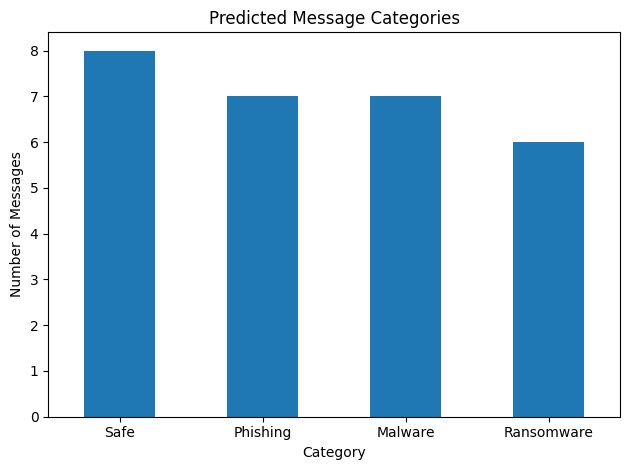

In [15]:
order = ['Safe', 'Phishing', 'Malware', 'Ransomware']

df['predicted_category'].value_counts().reindex(
    order, fill_value=0
).plot(kind='bar')

plt.title('Predicted Message Categories')
plt.xlabel('Category')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
new_message = input("Enter a new message: ")

prediction, matched, score = classify_message(new_message)

temp_row = pd.Series({
    'predicted_category': prediction,
    'keyword_score': score
})

risk, action = add_risk_and_action(temp_row)

print("Predicted category:", prediction)
print("Matched keywords:", matched)
print("Keyword score:", score)
print("Risk level:", risk)
print("Recommended action:", action)

Enter a new message: Urgent: verify your bank password by clicking here
Predicted category: Phishing
Matched keywords: verify, password, urgent, bank
Keyword score: 4
Risk level: High
Recommended action: Do not click/open; isolate if required and report.


Q5: Responsible Use and Reflection

1. Privacy:
Cybersecurity messages may contain sensitive information, so user data should be handled securely and only used when necessary.

2. Bias:
Keyword-based rules may be biased because certain words may appear in legitimate messages and may not represent an actual threat.

3. False Alarms:
The system can incorrectly classify a safe message as a threat, so predictions should not be treated as 100% accurate.

4. Accountability:
A human should remain responsible for important cybersecurity decisions instead of relying completely on an automated system.

5. Human Review:
High-risk or uncertain messages should be reviewed by a human before taking serious action.

In [17]:
df.to_csv('/content/Lab1_Final_Result.csv', index=False)

print('Final result saved successfully!')
print('File: /content/Lab1_Final_Result.csv')

Final result saved successfully!
File: /content/Lab1_Final_Result.csv


In [18]:
from google.colab import files

files.download('/content/Lab1_Final_Result.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
print("Total messages:", len(df))

print("\nFinal columns:")
print(df.columns.tolist())

print("\nFinal Result Preview:")
display(df.head())

Total messages: 28

Final columns:
['message_id', 'message', 'correct_category', 'predicted_category', 'matched_keywords', 'keyword_score', 'correct', 'risk_level', 'recommended_action']

Final Result Preview:


,message_id,message,correct_category,predicted_category,matched_keywords,keyword_score,correct,risk_level,recommended_action
0,1,The department meeting is scheduled for 2 PM i...,Safe,Safe,,0,True,Low,Continue normal caution.
1,2,Your account will be suspended. Click here and...,Phishing,Phishing,"click here, verify, password, urgent",4,True,High,Do not click/open; isolate if required and rep...
2,3,The attached executable file contains a trojan...,Malware,Malware,"trojan, executable",2,True,High,Do not click/open; isolate if required and rep...
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware,Ransomware,"encrypted, bitcoin, restore files",3,True,High,Do not click/open; isolate if required and rep...
4,5,Library books must be returned before Friday.,Safe,Safe,,0,True,Low,Continue normal caution.
